# Dataset, MobileNetV2 e Fine Tuning

## Addestramento del secondo modello per gli attacchi black-box

Questo notebook addestra MobileNetV2 sullo stesso dataset con lo stesso preprocesso utilizzato per ResNet18

## 1. Setup e Import

In [14]:
import os
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plot
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm

%matplotlib inline

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

ROOT = Path('..')
BATCH_SIZE = 32
IMG_SIZE = 224
N_CLASSES = 5

print(f"Setup e import completati")

Setup e import completati


## 2. Normalizzazione e trasformazioni

Stesse trasformazioni del modello ResNet

In [15]:
NORMALIZE = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

TRAIN_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.AutoAugment(transforms.AutoAugmentPolicy.IMAGENET),
    transforms.ToTensor(),
    NORMALIZE
])

VAL_TEST_TRANSFORMS = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    NORMALIZE
])

## 3. Dataset e DataLoader

Vengono utilizzati gli stessi split train, validation e test usati per ResNet18

In [16]:
dataset_path = ROOT / "data" / "fruits-classification-stratified"

train_dataset = ImageFolder(root=dataset_path / 'train', transform=TRAIN_TRANSFORMS)

val_dataset = ImageFolder(root=dataset_path / 'valid', transform=VAL_TEST_TRANSFORMS)

test_dataset = ImageFolder(root=dataset_path / 'test', transform=VAL_TEST_TRANSFORMS)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

class_names = test_dataset.classes

print("Dataset e DataLoader creati")
print(f"Train: {len(train_dataset)} immagini")
print(f"Validation: {len(val_dataset)} immagini")
print(f"Test: {len(test_dataset)} immagini")
print(f"Classi: {class_names}")
print(f"Class mapping: {test_dataset.class_to_idx}")

Dataset e DataLoader creati
Train: 7980 immagini
Validation: 998 immagini
Test: 998 immagini
Classi: ['Apple', 'Banana', 'Grape', 'Mango', 'Strawberry']
Class mapping: {'Apple': 0, 'Banana': 1, 'Grape': 2, 'Mango': 3, 'Strawberry': 4}


# MobileNetV2 e Fine Tuning

## 1. Caricamento di MobileNetV2

MobileNetV2 viene caricata con pesi pre-addestrati su ImageNet

In [17]:
weights = models.MobileNet_V2_Weights.IMAGENET1K_V1
model = models.mobilenet_v2(weights=weights)

model = model.to(device)

print("MobileNetV2 caricata con pesi pre-addestrati")
print(f"Modello spostato su: {device}")

MobileNetV2 caricata con pesi pre-addestrati
Modello spostato su: cuda


## 2. Architettura e parametri del modello

In [18]:
print("Struttura MobileNetV2:")
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(
    p.numel() for p in model.parameters()
    if p.requires_grad
)

print(f"\nParametri totali: {total_params:,}")
print(f"Parametri addestrabili: {trainable_params:,}")

Struttura MobileNetV2:
MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride

## 3. Adattamento del modello

Il MobileNetV2 produce 1000 output, bisogna sostituire l'ultimo layer con un layer che produce le 5 classi del dataset

In [19]:
in_features = model.classifier[1].in_features

model.classifier[1] = nn.Linear(in_features=in_features, out_features=N_CLASSES).to(device)

print(f"Nuovo output: {model.classifier[1].out_features} classi")
print(f"\nModello adattato per il dataset corrente")

Nuovo output: 5 classi

Modello adattato per il dataset corrente


## 4. Fine tuning

In [20]:
# MobileNetV2 contiene 19 blocchi in model.features
# congelo i primi 15 blocchi
for param in model.features[:15].parameters():
    param.requires_grad = False

print("Primi 15 blocchi congelati (non si addestrano)")
print("Ultimi 4 blocchi e classificatore rimangono trainabili")

# ricalcolo i parametri dopo aver modificato il classificatore
total_params = sum(p.numel() for p in model.parameters())

trainable_params_after = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"\nParametri totali: {total_params:,}")
print(f"Parametri trainabili: {trainable_params_after:,}")

Primi 15 blocchi congelati (non si addestrano)
Ultimi 4 blocchi e classificatore rimangono trainabili

Parametri totali: 2,230,277
Parametri trainabili: 1,532,485


## 5. Loss Function e Optimizer

In [21]:
loss_fn = nn.CrossEntropyLoss()

learning_rate = 0.0001
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print("Loss Function: CrossEntropyLoss")
print("Optimizer: Adam")
print(f"Learning Rate: {learning_rate}")

print("\nFinetuning completato")

Loss Function: CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.0001

Finetuning completato


# Training

## 1. Funzione di training e validazione

In [22]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, device):
    """
    Esegue un'epoca di training
    
    Ritorna: (avg_loss, accuracy)
    """
    model.train()  # modalita training
    
    tot_loss = 0
    correct_preds = 0
    tot_preds = 0
    
    for images, labels in tqdm(train_loader, desc="Training"):   # itera su tutti i batch di training con barra di progresso
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass: calcolo delle predizioni
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        
        # Backward pass: calcolo dei gradienti
        optimizer.zero_grad()  # pulisce i gradienti vecchi
        loss.backward()  # calcola nuovi gradienti
        optimizer.step()  # aggiorna i pesi
        
        tot_loss += loss.item()
        predicted = torch.argmax(outputs, dim=1)  # prendo la classe con score massimo
        correct_preds += (predicted == labels).sum().item()
        tot_preds += labels.size(0)
    
    avg_loss = tot_loss / len(train_loader)
    accuracy = correct_preds / tot_preds
    
    return avg_loss, accuracy

print("Funzione train_one_epoch() definita")

def val_one_epoch(model, val_loader, loss_fn, device):
    """
    Esegue un'epoca di validazione
    
    Ritorna: (avg_loss, accuracy)
    """
    model.eval()  # mette il modello in modalità evaluation (no dropout, no batch norm updates)
    
    tot_loss = 0
    correct_preds = 0
    tot_preds = 0
    
    # torch.no_grad() dice a PyTorch di non calcolare i gradienti (più veloce)
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc="Validation"):
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass: calcola le predizioni
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            
            tot_loss += loss.item()
            predicted = torch.argmax(outputs, dim=1)
            correct_preds += (predicted == labels).sum().item()
            tot_preds += labels.size(0)
    
    avg_loss = tot_loss / len(val_loader)
    accuracy = correct_preds / tot_preds
    
    return avg_loss, accuracy

print("Funzione val_one_epoch() definita")

Funzione train_one_epoch() definita
Funzione val_one_epoch() definita


## 2. Parametri del training

In [23]:
n_epochs = 50
best_val_loss = float('inf')

model_save_path = ROOT / "models" / "best_mobilenet_v2.pt"
model_save_path.parent.mkdir(parents=True, exist_ok=True)

patience = 20
patience_counter = 0

metrics = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': [],
    'epoch_time': []
}

print(f"Numero massimo di epoche: {n_epochs}")
print(f"Early Stopping patience: {patience}")
print(f"Modello salvato in: {model_save_path}")

Numero massimo di epoche: 50
Early Stopping patience: 20
Modello salvato in: ../models/best_mobilenet_v2.pt


## 3. Loop principale del training

In [24]:
# Training loop principale con Early Stopping
start_time_tot = time.time()  # inizio timing totale

for epoch in range(n_epochs):
    start_time_epoch = time.time()  # inizio timing per epoca
        
    # Training
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, device)
    
    # Validazione
    val_loss, val_acc = val_one_epoch(model, val_loader, loss_fn, device)
    
    # calcola tempo per epoca
    epoch_time = time.time() - start_time_epoch
    
    metrics['train_loss'].append(train_loss)
    metrics['train_acc'].append(train_acc)
    metrics['val_loss'].append(val_loss)
    metrics['val_acc'].append(val_acc)
    metrics['epoch_time'].append(epoch_time)
    
    # Early Stopping: controlla se c'è miglioramento
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), model_save_path)
        patience_counter = 0  # reset counter
        print(f"Nuovo migliore modello salvato (Val Loss: {val_loss:.4f})\n")
    else:
        patience_counter += 1
        print("Nessun miglioramento\n")
    
    # Early Stopping: ferma se nessun miglioramento per 'patience' epoche
    if patience_counter >= patience:
        print(f"Early Stopping! Nessun miglioramento per {patience} epoche consecutive")
        print(f"Training fermato alla epoca {epoch+1}")
        break


print("\nTRAINING COMPLETATO")

# calcolo tempo totale formattato
tot_time = time.time() - start_time_tot
hours = int(tot_time // 3600)
minutes = int((tot_time % 3600) // 60)
seconds = int(tot_time % 60)
tot_time_formatted = f"{hours:02d}:{minutes:02d}:{seconds:02d}"

# DataFrame per le metriche
metrics_df = pd.DataFrame(metrics)
metrics_df.index.name = 'Epoca'
metrics_df.index = metrics_df.index+1 

print("\nMetriche:")
print(metrics_df.to_string())

print(f"\nTempi di training:")
print(f"  Tempo totale: {tot_time_formatted}")
print(f"  Tempo per epoca (media): {np.mean(metrics['epoch_time']):.2f}s")

Validation: 100%|██████████| 32/32 [00:00<00:00, 96.50it/s] 


Nuovo migliore modello salvato (Val Loss: 0.3281)



Validation: 100%|██████████| 32/32 [00:00<00:00, 94.56it/s] 


Nuovo migliore modello salvato (Val Loss: 0.2861)



Validation: 100%|██████████| 32/32 [00:00<00:00, 92.98it/s] 


...

Nessun miglioramento



Validation: 100%|██████████| 32/32 [00:00<00:00, 90.07it/s] 


Nessun miglioramento



Validation: 100%|██████████| 32/32 [00:00<00:00, 92.29it/s] 

Nessun miglioramento

Early Stopping! Nessun miglioramento per 20 epoche consecutive
Training fermato alla epoca 26

TRAINING COMPLETATO

Metriche:
       train_loss  train_acc  val_loss   val_acc  epoch_time
Epoca                                                       
1        0.643244   0.765038  0.328118  0.870741    2.895610
2        0.424638   0.849248  0.286103  0.894790    2.925859
3        0.369684   0.867043  0.277973  0.899800    2.970747
4        0.326520   0.885088  0.247389  0.912826    3.000184
5        0.293438   0.897870  0.247994  0.914830    2.957726
6        0.267296   0.907268  0.216037  0.925852    2.995432
7        0.246784   0.912030  0.216884  0.923848    3.004021
8        0.214174   0.922807  0.233646  0.917836    2.953034
9        0.215382   0.925313  0.230195  0.925852    2.992779
10       0.187730   0.934085  0.238273  0.922846    2.990163
11       0.189106   0.934837  0.238403  0.923848    3.017447
12       0.177264   0.941353  0.250851  0.918838    3.01352

## 4. Valutazione sul test set

In [25]:
model.load_state_dict(torch.load(model_save_path, map_location=device))

model.eval()

test_loss, test_acc = val_one_epoch(model, test_loader, loss_fn, device)

print("Risultati TEST SET")
print(f" Test Loss: {test_loss:.4f}")
print(f" Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Validation:   0%|          | 0/32 [00:00<?, ?it/s]

Validation: 100%|██████████| 32/32 [00:00<00:00, 89.87it/s] 

Risultati TEST SET
 Test Loss: 0.1974
 Test Accuracy: 0.9309 (93.09%)


## 5. Visualizzazioni

Curve di training salvate in: ../results/MobileNetV2_training_curves.png


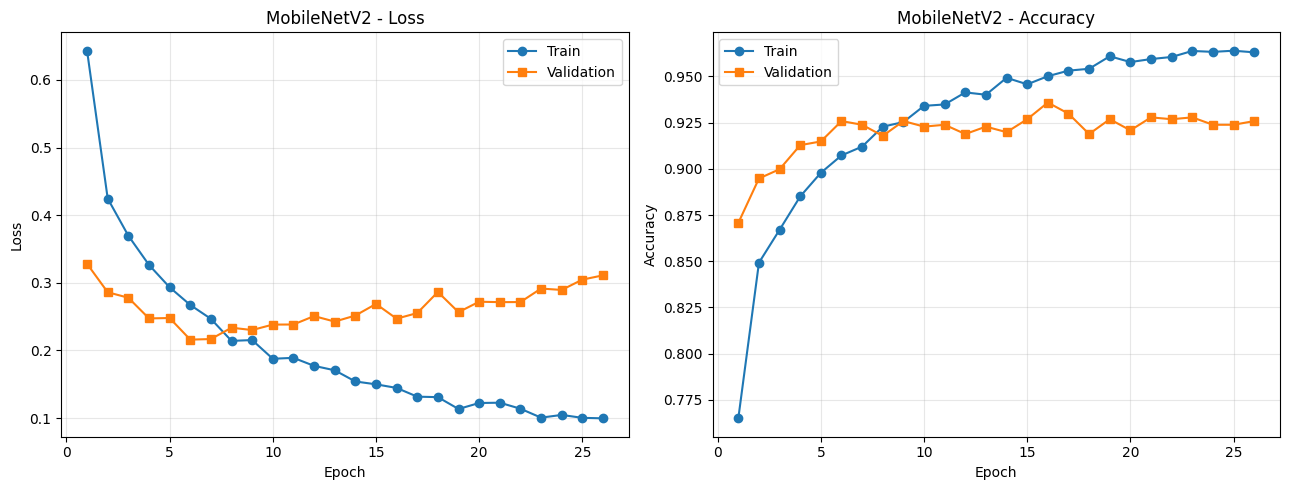

Predizioni sul test set: 100%|██████████| 32/32 [00:00<00:00, 91.68it/s] 



Confusion Matrix:
[[170   7   7  10   5]
 [  0 198   0   1   0]
 [ 10   3 182   2   3]
 [  6   5   1 188   0]
 [  4   1   3   1 191]]

Confusion Matrix salvata in: ../results/MobileNetV2_confusion_matrix.png


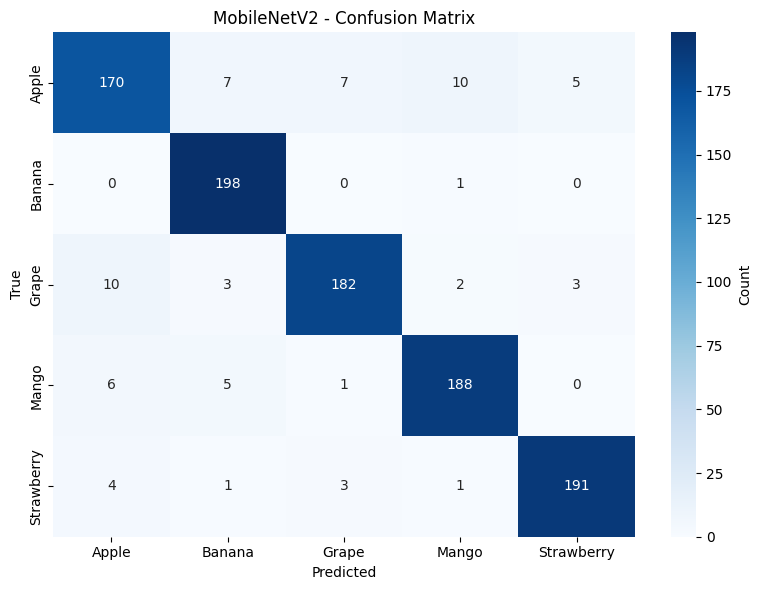


Classification Report:
              precision    recall  f1-score   support

       Apple       0.89      0.85      0.87       199
      Banana       0.93      0.99      0.96       199
       Grape       0.94      0.91      0.93       200
       Mango       0.93      0.94      0.94       200
  Strawberry       0.96      0.95      0.96       200

    accuracy                           0.93       998
   macro avg       0.93      0.93      0.93       998
weighted avg       0.93      0.93      0.93       998


Classification Report salvato in: ../results/MobileNetV2_classification_report.png


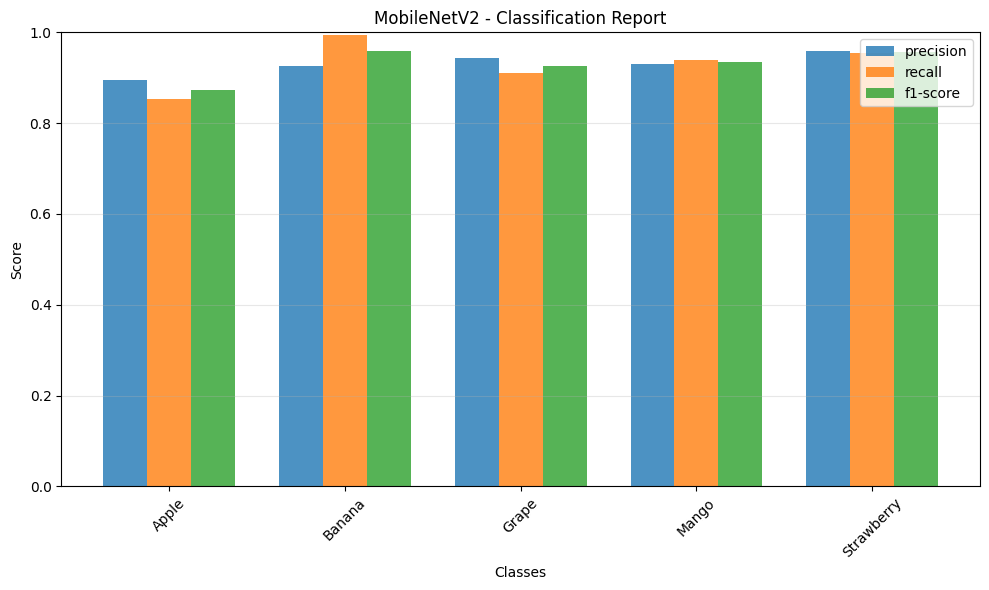


Esempi di predizioni salvati in: ../results/MobileNetV2_predictions.png


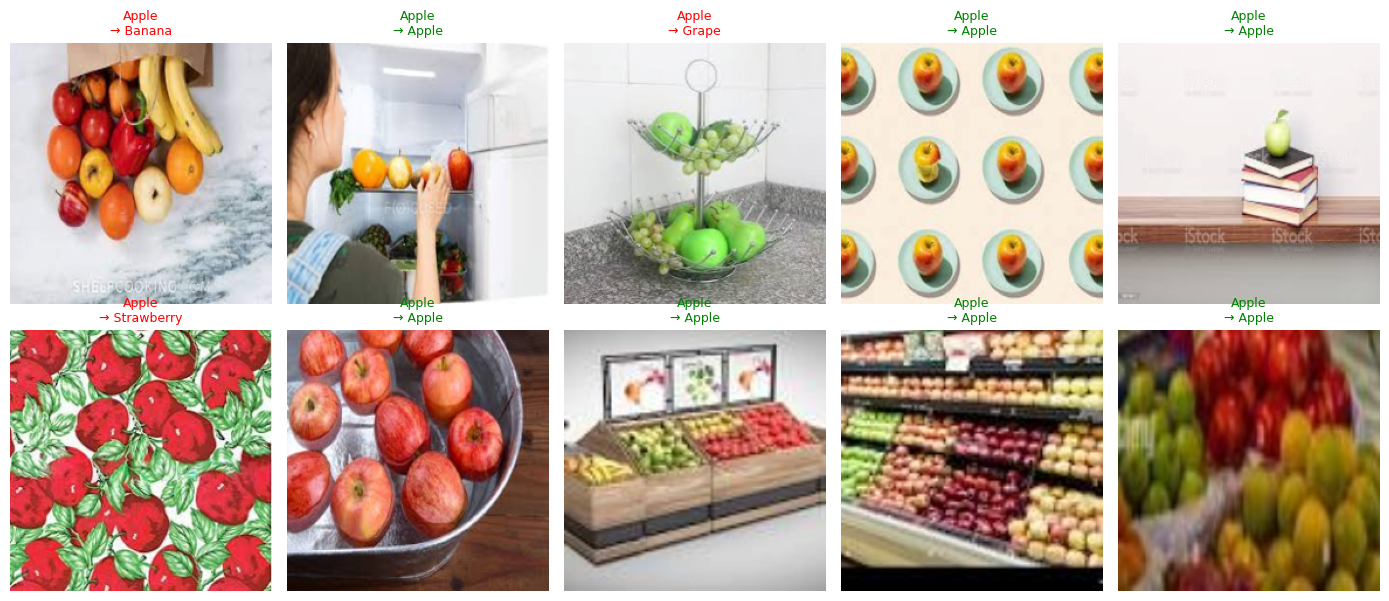


Riepilogo MobileNetV2
      model  learning_rate  max_epochs  epochs_completed  best_epoch  train_loss_final  train_accuracy_final  best_val_loss  val_accuracy_at_best_loss  test_loss  test_accuracy  training_time_s
MobileNetV2         0.0001          50                26           6          0.099643              0.963033       0.216037                   0.925852   0.197448       0.930862        77.903245

Metriche salvate in:
../results/MobileNetV2_metrics_summary.csv

Visualizzazioni completate


In [27]:
results_path = ROOT / "results"
results_path.mkdir(exist_ok=True)

# curve di training
epochs = range(1, len(metrics['train_loss']) + 1)

fig, (ax1, ax2) = plot.subplots(1, 2, figsize=(13, 5))

# loss
ax1.plot(
    epochs,
    metrics['train_loss'],
    'o-',
    label='Train'
)

ax1.plot(
    epochs,
    metrics['val_loss'],
    's-',
    label='Validation'
)

ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('MobileNetV2 - Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# accuracy
ax2.plot(
    epochs,
    metrics['train_acc'],
    'o-',
    label='Train'
)

ax2.plot(
    epochs,
    metrics['val_acc'],
    's-',
    label='Validation'
)

ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('MobileNetV2 - Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)

plot.tight_layout()

plot.savefig(
    results_path / "MobileNetV2_training_curves.png",
    dpi=300,
    bbox_inches='tight'
)

print(
    "Curve di training salvate in:",
    results_path / "MobileNetV2_training_curves.png"
)

plot.show()

# predizioni
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(
        test_loader,
        desc="Predizioni sul test set"
    ):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        predicted = torch.argmax(outputs, dim=1)

        all_predictions.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


# confusion matrix
cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("\nConfusion Matrix:")
print(cm)

fig, ax = plot.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    ax=ax,
    cbar_kws={'label': 'Count'}
)

ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title('MobileNetV2 - Confusion Matrix')

plot.tight_layout()

plot.savefig(
    results_path / "MobileNetV2_confusion_matrix.png",
    dpi=300,
    bbox_inches='tight'
)

print(
    "\nConfusion Matrix salvata in:",
    results_path / "MobileNetV2_confusion_matrix.png"
)

plot.show()

# classification report
print("\nClassification Report:")

class_report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    output_dict=True
)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names
    )
)

metrics_types = [
    'precision',
    'recall',
    'f1-score'
]

data_to_plot = []

for metric in metrics_types:
    values = [
        class_report[class_name][metric]
        for class_name in class_names
    ]

    data_to_plot.append(values)

x = np.arange(len(class_names))
width = 0.25

fig, ax = plot.subplots(figsize=(10, 6))

for i, (metric, values) in enumerate(
    zip(metrics_types, data_to_plot)
):
    ax.bar(
        x + i * width,
        values,
        width,
        label=metric,
        alpha=0.8
    )

ax.set_xlabel('Classes')
ax.set_ylabel('Score')
ax.set_title('MobileNetV2 - Classification Report')
ax.set_xticks(x + width)
ax.set_xticklabels(class_names, rotation=45)
ax.set_ylim(0, 1)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plot.tight_layout()

plot.savefig(
    results_path / "MobileNetV2_classification_report.png",
    dpi=300,
    bbox_inches='tight'
)

print(
    "\nClassification Report salvato in:",
    results_path / "MobileNetV2_classification_report.png"
)

plot.show()


# esempi di predizioni
images, labels = next(iter(test_loader))

images = images.to(device)
labels = labels.to(device)

with torch.no_grad():
    outputs = model(images)
    predicted = torch.argmax(outputs, dim=1)

n_examples = min(10, images.size(0))

fig, axes = plot.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(n_examples):
    image = images[i].cpu().numpy()
    image = np.transpose(image, (1, 2, 0))

    # rimozione della normalizzazione ImageNet
    image = (
        image * np.array([0.229, 0.224, 0.225])
        + np.array([0.485, 0.456, 0.406])
    )

    image = np.clip(image, 0, 1)

    true_label = class_names[labels[i].item()]
    predicted_label = class_names[predicted[i].item()]

    color = (
        'green'
        if true_label == predicted_label
        else 'red'
    )

    axes[i].imshow(image)

    axes[i].set_title(
        f"{true_label}\n→ {predicted_label}",
        color=color,
        fontsize=9
    )

    axes[i].axis('off')

for i in range(n_examples, len(axes)):
    axes[i].axis('off')

plot.tight_layout()

plot.savefig(
    results_path / "MobileNetV2_predictions.png",
    dpi=300,
    bbox_inches='tight'
)

print(
    "\nEsempi di predizioni salvati in:",
    results_path / "MobileNetV2_predictions.png"
)

plot.show()

# metriche
best_epoch = np.argmin(metrics['val_loss'])

summary_df = pd.DataFrame([{
    'model': 'MobileNetV2',
    'learning_rate': learning_rate,
    'max_epochs': n_epochs,
    'epochs_completed': len(metrics['train_loss']),
    'best_epoch': best_epoch + 1,
    'train_loss_final': metrics['train_loss'][-1],
    'train_accuracy_final': metrics['train_acc'][-1],
    'best_val_loss': metrics['val_loss'][best_epoch],
    'val_accuracy_at_best_loss': metrics['val_acc'][best_epoch],
    'test_loss': test_loss,
    'test_accuracy': test_acc,
    'training_time_s': tot_time
}])

summary_df.to_csv(
    results_path / "MobileNetV2_metrics_summary.csv",
    index=False
)

print("\nRiepilogo MobileNetV2")
print(summary_df.to_string(index=False))

print("\nMetriche salvate in:")
print(results_path / "MobileNetV2_metrics_summary.csv")

print("\nVisualizzazioni completate")